In [10]:
from LightGBM import *
from dataset_preprocess import combine_occupation_values
import pandas as pd
import warnings as wr


wr.filterwarnings('ignore')

data = extract_data()
score = train(data, False)
print(f"default_score: {score}")
Kfold_CV(data)

default_score: 0.8182630774246568
Her Fold'un AUC Skorları: [0.8307, 0.8308, 0.8066, 0.8166, 0.8196]
Ortalama CV AUC Skoru: 0.8208 (+/- 0.0092)


In [2]:
def combine_marital_status(data):
    data["maritalStatus_Divorced_Widowed"] = (
        data["maritalStatus_Divorced"] | data["maritalStatus_Widowed"]).astype(int)
    data = data.drop(columns=['maritalStatus_Divorced', 'maritalStatus_Widowed'])
    return data

X_train, X_test, y_train, y_test = data
X_train_modified = combine_marital_status(X_train.copy())
X_test_modified = combine_marital_status(X_test.copy())
combine_maritals = (X_train_modified, X_test_modified, y_train, y_test)

score_combined_maritals = train(combine_maritals, False)
print(f"score_combined_maritals: {score_combined_maritals}")

score_combined_maritals: 0.8163722496686888


In [3]:
df = pd.read_csv("Dataset/in-vehicle-coupon-recommendation.csv")
X_train, X_test, y_train, y_test = create_train_test_datasets(df)
X_train = combine_occupation_values(X_train)
X_test = combine_occupation_values(X_test)
X_train, X_test = encode_train_test_datasets(X_train, X_test, y_train, True)

data_combined_occupation = (X_train, X_test, y_train, y_test)

score_combined_occupation = train(data_combined_occupation, False)
print(f"score_combined_occupation: {score_combined_occupation}")
Kfold_CV(data_combined_occupation)

score_combined_occupation: 0.8189708567845295
Her Fold'un AUC Skorları: [0.8279, 0.8279, 0.8044, 0.8189, 0.8159]
Ortalama CV AUC Skoru: 0.8190 (+/- 0.0087)


In [4]:
data = extract_data()
X_train, X_test, y_train, y_test = data
X_train['education'] = X_train['education'].replace(0, 1)
X_test['education'] = X_test['education'].replace(0, 1)
data_combined_education = (X_train, X_test, y_train, y_test)

score_combined_education = train(data_combined_education, False)
print(f"score_combined_education: {score_combined_education}")

score_combined_education: 0.8170166171221113


In [5]:
data = extract_data()
X_train, X_test, y_train, y_test = data

X_train = X_train.drop(columns=['destination_Work'])
X_test = X_test.drop(columns=['destination_Work'])
data_removed_destination = (X_train, X_test, y_train, y_test)

score_removed_destination = train(data_removed_destination, False)
print(f"score_removed_destination: {score_removed_destination}")

score_removed_destination: 0.8182630774246568


In [6]:
data = extract_data()
X_train, X_test, y_train, y_test = data

X_train = X_train.drop(columns=['destination_No Urgent Place'])
X_test = X_test.drop(columns=['destination_No Urgent Place'])
data_removed_destination_nup = (X_train, X_test, y_train, y_test)

score_removed_destination_nup = train(data_removed_destination_nup, False)
print(f"score_removed_destination_nup: {score_removed_destination_nup}")

score_removed_destination_nup: 0.8114914544449505


In [7]:
data = extract_data()
X_train, X_test, y_train, y_test = data

X_train = X_train.drop(columns=['weather_Snowy'])
X_test = X_test.drop(columns=['weather_Snowy'])
data_removed_weather = (X_train, X_test, y_train, y_test)

score_removed_weather = train(data_removed_weather, False)
print(f"score_removed_weather: {score_removed_weather}")

score_removed_weather: 0.8152654236651955


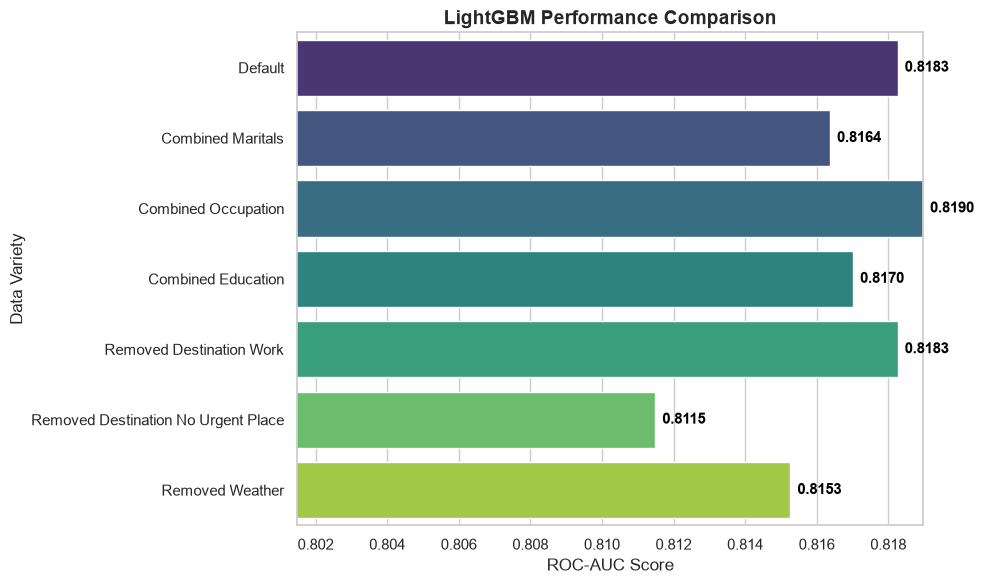

In [8]:
results = {
    "Default": score,
    "Combined Maritals": score_combined_maritals,
    "Combined Occupation": score_combined_occupation,
    "Combined Education": score_combined_education,
    "Removed Destination Work": score_removed_destination,
    "Removed Destination No Urgent Place": score_removed_destination_nup,
    "Removed Weather": score_removed_weather
}
compare_results(results)


In [9]:
learn_best_params(data)

En iyi parametreler: {'boosting_type': 'gbdt', 'n_estimators': 582, 'learning_rate': 0.09135301766719553, 'max_depth': 6, 'num_leaves': 110, 'min_child_samples': 21, 'subsample': 0.9841372878332021, 'colsample_bytree': 0.6359476359169153}
En iyi AUC Skoru: 0.8356
